# Poligrafo: spider-level EDA

Fixed sections:
1. Run selection and player evidence
2. Volume, temporal coverage, and quality overview
3. Text-length histograms by original_label and standard_label
4. Category, topic/tag, and temporal distribution
5. Missing fields and invalid dates
6. Cleaning and normalization review
7. NLP with stop-word removal, lemmas, and NER
8. Processed JSONL export


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display


def _find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().resolve().parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Repositorio nao encontrado a partir do diretorio atual.")


REPO_ROOT = _find_repo_root()
for path in (REPO_ROOT, REPO_ROOT / "src", REPO_ROOT / "notebooks"):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

import eda_utils as eu

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 160)
sns.set_theme(style="whitegrid", palette="crest")

## Run selection and player evidence

In [2]:
SPIDER = "poligrafo"
PLAYER = "Poligrafo"
DATA_DIR = eu.resolve_data_dir(str(REPO_ROOT / "data"))
SNAPSHOT_ID = None
BATCH_SIZE = 64

selection = eu.select_spider_run(DATA_DIR, SPIDER)
profile = eu.get_spider_profile(SPIDER)
display(eu.selection_to_frame(selection))
profile

,spider,agency_id,agency_name,selected_run_id,latest_run_id,latest_valid_run_id,fallback_applied,selection_reason,cleaning_flags,diagnostic_run_ids
0,poligrafo,poligrafo,Poligrafo,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,latest_valid_run,"html_unescape, unicode_normalize, collapse_whitespace, light_encoding_fix",


SpiderProfile(spider='poligrafo', display_name='Poligrafo', analysis_field_order=('title', 'claim', 'summary'), ignored_analysis_titles=frozenset(), dropped_export_titles=frozenset(), extract_label_prefix_before_colon=False, diagnostic_run_ids=(), cleaning_flags=('html_unescape', 'unicode_normalize', 'collapse_whitespace', 'light_encoding_fix'))

In [3]:
runs_df = eu.load_runs_df(DATA_DIR)
spider_runs = runs_df.loc[runs_df["spider"] == SPIDER].sort_values(
    "run_started_at", ascending=False
)
evidence_cols = [
    "run_id",
    "run_started_at",
    "run_finished_at",
    "items_seen",
    "items_stored",
    "items_deduped",
    "items_invalid",
    "has_items_file",
    "is_valid",
]
display(spider_runs[evidence_cols].head(10))

diagnostic_df = eu.diagnostic_runs_df(DATA_DIR, SPIDER)
if not diagnostic_df.empty:
    print("Diagnostic runs configured for this spider:")
    display(diagnostic_df[evidence_cols])

,run_id,run_started_at,run_finished_at,items_seen,items_stored,items_deduped,items_invalid,has_items_file,is_valid
20,20260315T010005Z-1d265f16,2026-03-15 01:00:05+00:00,2026-03-15 07:03:08+00:00,555,555,0,0,True,True


## Volume, temporal coverage, and quality overview

In [4]:
nlp = eu.load_nlp_model()
raw_df = eu.load_spider_items_df(DATA_DIR, SPIDER, selection.selected_run_id)
selection, processed_records = eu.build_processed_records(
    DATA_DIR,
    SPIDER,
    selection=selection,
    nlp=nlp,
    batch_size=BATCH_SIZE,
)
processed_df = eu.processed_records_to_df(processed_records)
processed_df["published_at_dt"] = pd.to_datetime(
    processed_df["published_at"], utc=True, errors="coerce"
)

overview = pd.DataFrame(
    [
        {
            "player": PLAYER,
            "selected_run_id": selection.selected_run_id,
            "latest_run_id": selection.latest_run_id,
            "fallback_applied": selection.fallback_applied,
            "raw_rows": len(raw_df),
            "processed_rows": len(processed_df),
            "dropped_rows": len(raw_df) - len(processed_df),
            "coverage_start": processed_df["published_at_dt"].min(),
            "coverage_end": processed_df["published_at_dt"].max(),
            "invalid_dates": int(processed_df["published_at_dt"].isna().sum()),
            "missing_original_label": int(processed_df["original_label"].isna().sum()),
        }
    ]
)
display(overview)
display(raw_df.head(3))
display(processed_df.head(3))

,player,selected_run_id,latest_run_id,fallback_applied,raw_rows,processed_rows,dropped_rows,coverage_start,coverage_end,invalid_dates,missing_original_label
0,Poligrafo,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,555,555,0,2018-10-07 22:00:00+00:00,2026-03-11 15:00:00+00:00,142,20


,item_id,agency_id,agency_name,spider,source_url,canonical_url,title,published_at,collected_at,claim,summary,verdict,rating,language,country,topics,tags,entities,source_type,run_id,published_at_dt,collected_at_dt,lag_hours,title_len,claim_len,summary_len,canonical_host,source_equals_canonical
0,08e631e57f21b3f151fff62f00baa721116a3e4bb58a143aecaa5f74417b2957,poligrafo,Poligrafo,poligrafo,https://poligrafo.sapo.pt/fact-check/na-lota-de-quarteira-houve-peixe-a-ser-vendido-por-001e-kg-como-se-denuncia-nas-redes-sociais/,https://poligrafo.sapo.pt/fact-check/na-lota-de-quarteira-houve-peixe-a-ser-vendido-por-001e-kg-como-se-denuncia-nas-redes-sociais,"Na lota de Quarteira houve peixe a ser vendido por 0,01€/kg, como se denuncia nas redes sociais? — Polígrafo",2025-10-16T15:00:00,2026-03-15T02:52:43+00:00,"Na lota de Quarteira houve peixe a ser vendido por 0,01€/kg, como se denuncia nas redes sociais? — Polígrafo",No Facebook exibe-se um recibo com o valor que uma embarcação recebeu após a venda do peixe na lota de Quarteira. Aparentemente foram vendidas cavalas ao pr...,"Verdadeiro, mas…","Verdadeiro, mas…",pt-PT,PT,[Economia],[],[],fact_check,20260315T010005Z-1d265f16,2025-10-16 15:00:00+00:00,2026-03-15 02:52:43+00:00,3587.878611,108,108,186,poligrafo.sapo.pt,0.0
1,7d4c2e6152bab052d727520c32487e6be7c041b164114f6169fae63e9d3fd2ae,poligrafo,Poligrafo,poligrafo,https://poligrafo.sapo.pt/fact-check/portugal-baixou-para-a-cauda-da-uniao-europeia-em-investimento-publico-e-privado-durante-a-governacao-de-antonio-costa/,https://poligrafo.sapo.pt/fact-check/portugal-baixou-para-a-cauda-da-uniao-europeia-em-investimento-publico-e-privado-durante-a-governacao-de-antonio-costa,Portugal baixou para a “cauda da Europa” em investimento público e privado durante a governação de António Costa? — Polígrafo,2025-10-25T11:00:00,2026-03-15T02:52:43+00:00,Portugal baixou para a “cauda da Europa” em investimento público e privado durante a governação de António Costa? — Polígrafo,"Alega-se nas redes sociais que Portugal foi parar à ""cauda da Europa"" ao nível de investimento durante a governação do PS. A base para esta alegação é uma i...",Falso,Falso,pt-PT,PT,[Economia],[],[],fact_check,20260315T010005Z-1d265f16,2025-10-25 11:00:00+00:00,2026-03-15 02:52:43+00:00,3375.878611,125,125,420,poligrafo.sapo.pt,0.0
2,b03d20cd0677140a5d4d46d1db23ed045b1dfb459b2eadc2bdd67f236aecaf01,poligrafo,Poligrafo,poligrafo,https://poligrafo.sapo.pt/fact-check/portugal-recebeu-200-mil-milhoes-de-euros-da-uniao-europeia-nos-ultimos-20-anos/,https://poligrafo.sapo.pt/fact-check/portugal-recebeu-200-mil-milhoes-de-euros-da-uniao-europeia-nos-ultimos-20-anos,Portugal recebeu 200 mil milhões de euros da União Europeia nos últimos 20 anos? — Polígrafo,2025-10-19T9:00:00,2026-03-15T02:52:44+00:00,Portugal recebeu 200 mil milhões de euros da União Europeia nos últimos 20 anos? — Polígrafo,"A preços de 2021, Portugal recebeu cerca de 180 mil milhões de euros desde 1986, de acordo com dados fornecidos ao Polígrafo pelo Banco de Portugal.",Falso,Falso,pt-PT,PT,[Economia],[],[],fact_check,20260315T010005Z-1d265f16,2025-10-19 09:00:00+00:00,2026-03-15 02:52:44+00:00,3521.878889,92,92,148,poligrafo.sapo.pt,0.0


,record_id,source_record_id,dataset_id,source_url,published_at,language,title,author,subtitle,claim_text,body_text,analysis_text,text_for_ner,text_without_stopwords,lemmatized_text,original_label,standard_label,category,entities,variant,metadata.analysis_text_length,metadata.entity_count,metadata.spider,metadata.agency_id,metadata.agency_name,metadata.run_id,metadata.latest_run_id,metadata.fallback_applied,metadata.source_type,metadata.source_topics,metadata.source_tags,metadata.source_rating,published_at_dt
0,factcheck_scrape_poligrafo:08e631e57f21b3f151fff62f00baa721116a3e4bb58a143aecaa5f74417b2957,08e631e57f21b3f151fff62f00baa721116a3e4bb58a143aecaa5f74417b2957,factcheck_scrape_poligrafo,https://poligrafo.sapo.pt/fact-check/na-lota-de-quarteira-houve-peixe-a-ser-vendido-por-001e-kg-como-se-denuncia-nas-redes-sociais/,2025-10-16T15:00:00+00:00,pt-PT,"Na lota de Quarteira houve peixe a ser vendido por 0,01€/kg, como se denuncia nas redes sociais? — Polígrafo",None,None,"Na lota de Quarteira houve peixe a ser vendido por 0,01€/kg, como se denuncia nas redes sociais? — Polígrafo",No Facebook exibe-se um recibo com o valor que uma embarcação recebeu após a venda do peixe na lota de Quarteira. Aparentemente foram vendidas cavalas ao pr...,"na lota de quarteira houve peixe a ser vendido por 0,01€/kg, como se denuncia nas redes sociais? — polígrafo no facebook exibe-se um recibo com o valor que ...","na lota de quarteira houve peixe a ser vendido por 0,01€/kg, como se denuncia nas redes sociais? — polígrafo no facebook exibe-se um recibo com o valor que ...","lota quarteira houve peixe vendido 0,01€/kg denuncia redes sociais polígrafo facebook exibe-se recibo embarcação recebeu venda peixe lota quarteira aparente...","em o lota de quarteira haver peixe a ser vender por 0,01€/kg como se denunciar em o rede social polígrafo em o facebook exiber se um recibo com o valor que ...","Verdadeiro, mas...",misleading,Economia,"[{'text': 'facebook', 'label': 'MISC', 'start_char': 112, 'end_char': 120}]",claim_summary,295,1,poligrafo,poligrafo,Poligrafo,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,fact_check,[Economia],[],"Verdadeiro, mas...",2025-10-16 15:00:00+00:00
1,factcheck_scrape_poligrafo:7d4c2e6152bab052d727520c32487e6be7c041b164114f6169fae63e9d3fd2ae,7d4c2e6152bab052d727520c32487e6be7c041b164114f6169fae63e9d3fd2ae,factcheck_scrape_poligrafo,https://poligrafo.sapo.pt/fact-check/portugal-baixou-para-a-cauda-da-uniao-europeia-em-investimento-publico-e-privado-durante-a-governacao-de-antonio-costa/,2025-10-25T11:00:00+00:00,pt-PT,Portugal baixou para a “cauda da Europa” em investimento público e privado durante a governação de António Costa? — Polígrafo,None,None,Portugal baixou para a “cauda da Europa” em investimento público e privado durante a governação de António Costa? — Polígrafo,"Alega-se nas redes sociais que Portugal foi parar à ""cauda da Europa"" ao nível de investimento durante a governação do PS. A base para esta alegação é uma i...",portugal baixou para a “cauda da europa” em investimento público e privado durante a governação de antónio costa? — polígrafo alega-se nas redes sociais que...,portugal baixou para a “cauda da europa” em investimento público e privado durante a governação de antónio costa? — polígrafo alega-se nas redes sociais que...,portugal baixou cauda europa investimento público privado durante governação antónio costa polígrafo alega-se redes sociais portugal parar cauda europa inve...,portugal baixar para o cauda de o europa em investimento público e privado durante o governação de antónio costa polígrafo alegar se em o rede social que po...,Falso,false,Economia,"[{'text': 'portugal', 'label': 'LOC', 'start_char': 0, 'end_char': 8}, {'text': 'europa', 'label': 'LOC', 'start_char': 33, 'end_char': 39}, {'text': 'antón...",claim_summary,546,7,poligrafo,poligrafo,Poligrafo,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,fact_check,[Economia],[],Falso,2025-10-25 11:00:00+00:00
2,factch

## Text-length histograms by label

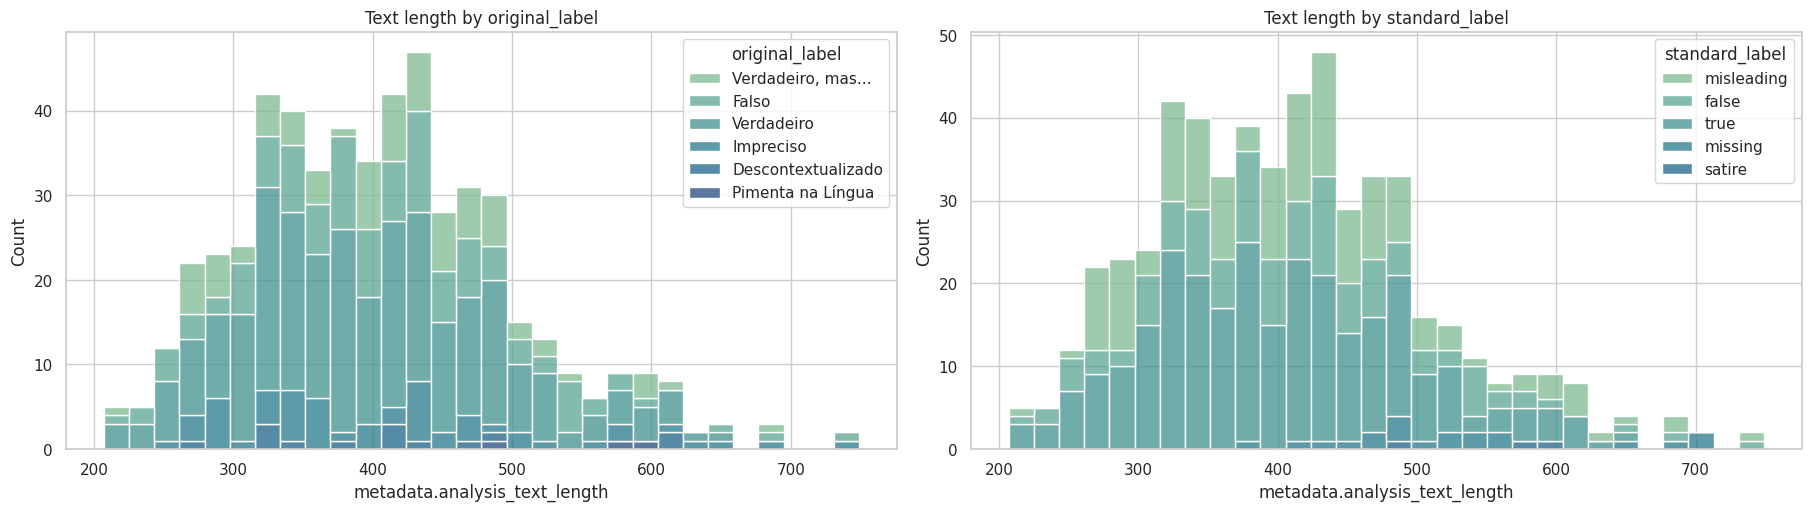

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5), constrained_layout=True)
sns.histplot(
    data=processed_df,
    x="metadata.analysis_text_length",
    hue="original_label",
    bins=30,
    multiple="stack",
    ax=axes[0],
)
axes[0].set_title("Text length by original_label")

sns.histplot(
    data=processed_df,
    x="metadata.analysis_text_length",
    hue="standard_label",
    bins=30,
    multiple="stack",
    ax=axes[1],
)
axes[1].set_title("Text length by standard_label")
plt.show()

## Category, topic/tag, temporal distribution, and data quality

In [6]:
topic_counts = raw_df["topics"].explode().dropna().value_counts().head(20)
tag_counts = raw_df["tags"].explode().dropna().value_counts().head(20)
category_counts = processed_df["category"].value_counts(dropna=False).head(20)

display(category_counts.rename_axis("category").reset_index(name="count"))
display(topic_counts.rename_axis("topic").reset_index(name="count"))
display(tag_counts.rename_axis("tag").reset_index(name="count"))

monthly = (
    processed_df.dropna(subset=["published_at_dt"])
    .assign(month=lambda df: df["published_at_dt"].dt.to_period("M").dt.to_timestamp())
    .groupby("month")
    .size()
    .reset_index(name="count")
)
display(monthly.tail(24))

missing_fields = (
    raw_df[["title", "claim", "summary", "verdict", "rating", "published_at"]]
    .isna()
    .sum()
    .rename_axis("field")
    .reset_index(name="missing_count")
)
display(missing_fields)

display(
    processed_df.loc[
        processed_df["published_at_dt"].isna(), ["source_record_id", "title", "published_at"]
    ].head(20)
)

,category,count
0,Economia,555


,topic,count
0,Economia,555


,tag,count


/tmp/ipykernel_2077697/1119197242.py:11: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .assign(month=lambda df: df["published_at_dt"].dt.to_period("M").dt.to_timestamp())


,month,count
57,2024-04-01,5
58,2024-05-01,2
59,2024-06-01,1
60,2024-07-01,1
61,2024-08-01,2
62,2024-09-01,3
63,2024-10-01,5
64,2024-11-01,2
65,2024-12-01,2
66,2025-01-01,1


,field,missing_count
0,title,0
1,claim,0
2,summary,0
3,verdict,20
4,rating,20
5,published_at,0


,source_record_id,title,published_at
2,b03d20cd0677140a5d4d46d1db23ed045b1dfb459b2eadc2bdd67f236aecaf01,Portugal recebeu 200 mil milhões de euros da União Europeia nos últimos 20 anos? — Polígrafo,NaN
6,1248b9df179189871799601b6a0ed8cf29195349734e3d68495ea5e77864351c,Mariana Leitão diz que “Portugal tem uma das taxas de poupança mais baixas da Europa”. Tem razão? — Polígrafo,NaN
12,a1c0bd9f39c1a03712852fd84866e5ca500cba789a7141fc2a18c731fab7a80a,Utilizadores do Passe Ferroviário Verde só podem reservar lugar nas 24 horas anteriores à viagem em comboios Intercidades? — Polígrafo,NaN
13,e28600f57e57b6318652a4a41f8c987c3ec3ffce769dbf040a266199f92ac1ce,É verdade que “80% dos vencimentos em Portugal é igual ou inferior a 1.500 euros brutos”? — Polígrafo,NaN
14,b96da2dc49ba3230baaa6a93b6217ad4be8fc7517a223aa81c6e36550377762b,"UE proibirá, a partir de 2027, pagamentos em dinheiro superiores a 10 mil euros? — Polígrafo",NaN
32,2ec9f4d7e963aef9d4e3f74bfeb2b07ca098078daa005fd7cdfacac20075eee1,"Banco de Portugal tem 1.700 funcionários, enquanto bancos centrais da Suíça e Suécia têm apenas 550 e 350 respetivamente? — Polígrafo",NaN
33,6f492d11b9c486abe97007310efd485805ce6590276e1b75134e6a087e5e26fb,Se o salário mínimo tivesse subido como o preço do pão desde 1990 já estaria nos 8.730 euros em 2023? — Polígrafo,NaN
37,cf8ab786dad681f0653977b1654165717f49bffa725c109a3ca372c3255d64c4,"“Por cada 10 euros de carregamento de um veículo elétrico, 7 euros são taxas” em Portugal? — Polígrafo",NaN
44,d49ca462cdc0741a11f9569f4ca72ecd76d07bd6b3dca6cf755394cd1382a6c2,Bónus extra fará com que reformado com pensão de 509 euros receba mais do que quem tem reforma de 510 euros no final do ano? — Polígrafo,NaN
51,3c6e20d828f715d57f566ec2a6c6f2e3f32798d5881ac0914194c1fad63a55c4,"Preços dos combustíveis: em Andorra o gasóleo comercializa-se a apenas €1,398 e a gasolina a €1,427? — Polígrafo",NaN


## Cleaning and normalization review

In [7]:
comparison = raw_df.rename(
    columns={
        "item_id": "source_record_id",
        "title": "raw_title",
        "claim": "raw_claim",
        "summary": "raw_summary",
        "published_at": "raw_published_at",
        "verdict": "raw_verdict",
    }
).merge(
    processed_df[
        [
            "source_record_id",
            "title",
            "claim_text",
            "body_text",
            "analysis_text",
            "original_label",
            "standard_label",
            "published_at",
        ]
    ],
    on="source_record_id",
    how="left",
)
display(comparison.head(15))

,source_record_id,agency_id,agency_name,spider,source_url,canonical_url,raw_title,raw_published_at,collected_at,raw_claim,raw_summary,raw_verdict,rating,language,country,topics,tags,entities,source_type,run_id,published_at_dt,collected_at_dt,lag_hours,title_len,claim_len,summary_len,canonical_host,source_equals_canonical,title,claim_text,body_text,analysis_text,original_label,standard_label,published_at
0,08e631e57f21b3f151fff62f00baa721116a3e4bb58a143aecaa5f74417b2957,poligrafo,Poligrafo,poligrafo,https://poligrafo.sapo.pt/fact-check/na-lota-de-quarteira-houve-peixe-a-ser-vendido-por-001e-kg-como-se-denuncia-nas-redes-sociais/,https://poligrafo.sapo.pt/fact-check/na-lota-de-quarteira-houve-peixe-a-ser-vendido-por-001e-kg-como-se-denuncia-nas-redes-sociais,"Na lota de Quarteira houve peixe a ser vendido por 0,01€/kg, como se denuncia nas redes sociais? — Polígrafo",2025-10-16T15:00:00,2026-03-15T02:52:43+00:00,"Na lota de Quarteira houve peixe a ser vendido por 0,01€/kg, como se denuncia nas redes sociais? — Polígrafo",No Facebook exibe-se um recibo com o valor que uma embarcação recebeu após a venda do peixe na lota de Quarteira. Aparentemente foram vendidas cavalas ao pr...,"Verdadeiro, mas…","Verdadeiro, mas…",pt-PT,PT,[Economia],[],[],fact_check,20260315T010005Z-1d265f16,2025-10-16 15:00:00+00:00,2026-03-15 02:52:43+00:00,3587.878611,108,108,186,poligrafo.sapo.pt,0.0,"Na lota de Quarteira houve peixe a ser vendido por 0,01€/kg, como se denuncia nas redes sociais? — Polígrafo","Na lota de Quarteira houve peixe a ser vendido por 0,01€/kg, como se denuncia nas redes sociais? — Polígrafo",No Facebook exibe-se um recibo com o valor que uma embarcação recebeu após a venda do peixe na lota de Quarteira. Aparentemente foram vendidas cavalas ao pr...,"na lota de quarteira houve peixe a ser vendido por 0,01€/kg, como se denuncia nas redes sociais? — polígrafo no facebook exibe-se um recibo com o valor que ...","Verdadeiro, mas...",misleading,2025-10-16T15:00:00+00:00
1,7d4c2e6152bab052d727520c32487e6be7c041b164114f6169fae63e9d3fd2ae,poligrafo,Poligrafo,poligrafo,https://poligrafo.sapo.pt/fact-check/portugal-baixou-para-a-cauda-da-uniao-europeia-em-investimento-publico-e-privado-durante-a-governacao-de-antonio-costa/,https://poligrafo.sapo.pt/fact-check/portugal-baixou-para-a-cauda-da-uniao-europeia-em-investimento-publico-e-privado-durante-a-governacao-de-antonio-costa,Portugal baixou para a “cauda da Europa” em investimento público e privado durante a governação de António Costa? — Polígrafo,2025-10-25T11:00:00,2026-03-15T02:52:43+00:00,Portugal baixou para a “cauda da Europa” em investimento público e privado durante a governação de António Costa? — Polígrafo,"Alega-se nas redes sociais que Portugal foi parar à ""cauda da Europa"" ao nível de investimento durante a governação do PS. A base para esta alegação é uma i...",Falso,Falso,pt-PT,PT,[Economia],[],[],fact_check,20260315T010005Z-1d265f16,2025-10-25 11:00:00+00:00,2026-03-15 02:52:43+00:00,3375.878611,125,125,420,poligrafo.sapo.pt,0.0,Portugal baixou para a “cauda da Europa” em investimento público e privado durante a governação de António Costa? — Polígrafo,Portugal baixou para a “cauda da Europa” em investimento público e privado durante a governação de António Costa? — Polígrafo,"Alega-se nas redes sociais que Portugal foi parar à ""cauda da Europa"" ao nível de investimento durante a governação do PS. A base para esta alegação é uma i...",portugal baixou para a “cauda da europa” em investimento público e privado durante a governação de antónio costa? — polígrafo alega-se nas redes sociais que...,Falso,false,2025-10-25T11:00:00+00:00
2,b03d20cd0677140a5d4d46d1db23ed045b1dfb459b2eadc2bdd67f236aecaf01,poligrafo,Poligrafo,poligrafo,https://poligrafo.sapo.pt/fact-check/portugal-recebeu-200-mil-milhoes-de-euros-da-uniao-europeia-nos-ultimos-20-anos/,https://poligrafo.sapo.pt/fact-check/portugal-recebeu-200-mil-milhoes-de-euros-da-uniao-europeia-nos-ultimos-20-anos,Portugal rece

## NLP outputs

In [8]:
lemma_counts = (
    processed_df["lemmatized_text"].str.split().explode().dropna().value_counts().head(20)
)
display(lemma_counts.rename_axis("lemma").reset_index(name="count"))

entity_series = processed_df["entities"].explode().dropna()
if entity_series.empty:
    entity_df = pd.DataFrame(columns=["text", "label", "start_char", "end_char"])
else:
    entity_df = pd.json_normalize(entity_series)

display(entity_df.head(20))
display(entity_df["label"].value_counts().rename_axis("label").reset_index(name="count"))
display(processed_df[["source_record_id", "text_without_stopwords", "lemmatized_text"]].head(10))

,lemma,count
0,o,5616
1,de,3918
2,em,2207
3,que,994
4,a,828
5,ser,749
6,polígrafo,667
7,um,658
8,e,575
9,se,532


,text,label,start_char,end_char
0,facebook,MISC,112,120
1,portugal,LOC,0,8
1,europa,LOC,33,39
1,antónio costa?,PER,99,113
1,portugal,LOC,157,165
1,europa,LOC,188,194
1,ps,ORG,245,247
1,europa,LOC,510,516
2,portugal,LOC,0,8
2,união europeia,ORG,45,59


,label,count
0,LOC,843
1,MISC,374
2,ORG,341
3,PER,264


,source_record_id,text_without_stopwords,lemmatized_text
0,08e631e57f21b3f151fff62f00baa721116a3e4bb58a143aecaa5f74417b2957,"lota quarteira houve peixe vendido 0,01€/kg denuncia redes sociais polígrafo facebook exibe-se recibo embarcação recebeu venda peixe lota quarteira aparente...","em o lota de quarteira haver peixe a ser vender por 0,01€/kg como se denunciar em o rede social polígrafo em o facebook exiber se um recibo com o valor que ..."
1,7d4c2e6152bab052d727520c32487e6be7c041b164114f6169fae63e9d3fd2ae,portugal baixou cauda europa investimento público privado durante governação antónio costa polígrafo alega-se redes sociais portugal parar cauda europa inve...,portugal baixar para o cauda de o europa em investimento público e privado durante o governação de antónio costa polígrafo alegar se em o rede social que po...
2,b03d20cd0677140a5d4d46d1db23ed045b1dfb459b2eadc2bdd67f236aecaf01,portugal recebeu 200 milhões euros união europeia últimos 20 anos polígrafo preços 2021 portugal recebeu cerca 180 milhões euros 1986 acordo dados fornecido...,portugal receber 200 mil milhão de euro de o união europeu em o último 20 ano polígrafo a preço de 2021 portugal receber cerca de 180 mil milhão de euro des...
3,88c9f0f7c4918346d25a0da088e253d1b05af56c30cef57971977dc284a25db1,portugal país ue preços casas vendidas distanciam intrínseco polígrafo publicação redes sociais destaca-se portugal país união europeia ue casas comercializ...,portugal ser o país de o ue onde o preço a que o casa ser vender mais se distancir de o seu valor intrínseco polígrafo em um publicação em o rede social des...
4,f74661698368c35d986b5f399f35409045f764a67935eb2530d34951ef265449,josé luís carneiro afirmou dívidas ativas aumentaram quase 900 milhões euros 2023 2024 razão polígrafo fonte oficial ps explicou afirmação josé luís carneir...,josé luís carneiro afirmar que o dívida ativo a o estado aumentar em quase 900 milhão de euros entre 2023 e 2024 ter razão polígrafo fonte oficial de o ps e...
5,f2797a2dc6bb328a0c1f328afc0393c39ec8f97286aa9ceb987d2b3bcb8791b6,lisboa cidade união europeia fatia salário médio destinada pagar renda polígrafo relatório união europeia comparou 22 cidades função peso renda salário médi...,lisboa ser o cidade de o união europeu onde um grande fatia de o salário médio ser destinar a pagar renda polígrafo um relatório de o conselho de o união eu...
6,1248b9df179189871799601b6a0ed8cf29195349734e3d68495ea5e77864351c,mariana leitão portugal taxas poupança baixas europa razão polígrafo publicação partilhada tiktok presidente iniciativa liberal afirmou continua penalizar t...,mariana leitão dizer que portugal ter um de o taxa de poupança mais baixo de o europa ter razão polígrafo em um publicação partilhar em o tiktok o president...
7,45898c985f35169bb8ecacb9909b6cd5ad84b32c9469e37fb5b2925f0bc388b4,oe2026 joão almeida cds-pp empresas pagam irc pagam maiores salários polígrafo durante dia debate proposta orçamento 2026 deputado centrista questionou verd...,oe2026 joão almeida cds-pp o empresa que mais pagar irc ser aquele que pagar maiore salário polígrafo durante o segundo dia de o debate sobre o proposta de ...
8,3152b1571c7d729f629a2f727177b3c5f18322e759e1dcc926495145b1fa4b1b,salário anual médio trabalhador inteiro portugal fica euros abaixo média europeia polígrafo acordo informação eurostat relativa 2024 salário anual médio tra...,salário anual médio por trabalhador a tempo inteiro em portugal ficar mais de dez mil euro abaixo de o média europeu polígrafo de acordo com informação de o...
9,9fff1e4790b00cec2ebb96fa9747d34e46c14ddeafc8263076f1268e3c9c1e0a,oe2026 mariana mortágua orçamento esconde milhões euros gastos militares polígrafo terça-feira durante dia apreciação generalidade orçamento 2026 coordenado...,oe2026 mariana mortágua orçamento esconder mil milhão de euro para gasto militar polígrafo este terça-feira durante o segundo dia de apreciação em o general...


## Export processed JSONL

In [9]:
export_info = eu.export_processed_records(
    DATA_DIR,
    SPIDER,
    records=processed_records,
    selection=selection,
    snapshot_id=SNAPSHOT_ID,
)

display(
    pd.DataFrame(
        [
            {
                "snapshot_id": export_info["snapshot_id"],
                "record_count": export_info["record_count"],
                "spider_path": str(export_info["spider_path"]),
                "combined_path": str(export_info["combined_path"]),
                "manifest_path": str(export_info["manifest_path"]),
            }
        ]
    )
)

,snapshot_id,record_count,spider_path,combined_path,manifest_path
0,20260316T000227Z-poligrafo,555,/home/diacrono/Documentos/repositorios/fact-checking-scrape/data/processed/20260316T000227Z-poligrafo/spiders/poligrafo.jsonl,/home/diacrono/Documentos/repositorios/fact-checking-scrape/data/processed/20260316T000227Z-poligrafo/factcheck_scrape_unified.jsonl,/home/diacrono/Documentos/repositorios/fact-checking-scrape/data/processed/20260316T000227Z-poligrafo/manifest.json
